In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("ws/ecommerce_dirty_dataset.csv")

In [3]:
df

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode
0,1,2022-04-13,2022-04-14,1992,Consumer,East,Odisha,Clothing,Kids,Kids Product 3,14492.00,5,0.20,1621.85,328.0,Cash on Delivery
1,2,2023-03-12,2023-03-13,4347,Corporate,East,Bihar,Electronics,Laptop,Laptop Product 100,47633.00,1,0.05,5774.48,340.0,Cash on Delivery
2,3,2022-09-28,2022-10-04,2195,Corporate,West,Maharashtra,Clothing,Women,Women Product 1,4058.10,1,0.10,521.04,348.0,Credit Card
3,4,2022-04-17,2022-04-21,3425,Consumer,South,Tamil Nadu,Electronics,Laptop,Laptop Product 139,61980.00,4,0.00,6695.36,62.0,Cash on Delivery
4,5,2022-03-13,2022-03-20,2967,NaN,North,Haryana,Clothing,Women,Women Product 50,6807.00,3,0.00,2653.83,94.0,Debit Card
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100495,79219,2023-10-02,2023-10-03,4301,Corporate,East,Odisha,Furniture,Chair,Chair Product 52,2667.00,1,0.00,829.68,185.0,Credit Card
100496,36298,2023-06-02,2023-06-05,4770,Consumer,North,Haryana,Furniture,Table,Table Product 2,56026.25,5,0.05,8928.97,217.0,Credit Card
100497,80041,2023-03-28,2023-04-02,3689,Consumer,East,Bihar,Furniture,Chair,Chair Product 55,22953.00,5,0.30,6327.46,95.0,Debit Card
100498,15667,2023-07-18,2023-07-20,1380,Corporate,West,Gujarat,Electronics,Laptop,Laptop Product 172,289241.75,5,0.05,106184.34,462.0,Credit Card


# PHASE 1 – DATA CLEANING

In [4]:
df.isnull().sum()

Order_ID               0
Order_Date             0
Ship_Date              0
Customer_ID            0
Customer_Segment    3019
Region                 0
State                  0
Product_Category       0
Sub_Category           0
Product_Name           0
Sales                  0
Quantity               0
Discount               0
Profit              3019
Shipping_Cost       3006
Payment_Mode           0
dtype: int64

In [5]:
df.shape



(100500, 16)

In [6]:
df.columns



Index(['Order_ID', 'Order_Date', 'Ship_Date', 'Customer_ID',
       'Customer_Segment', 'Region', 'State', 'Product_Category',
       'Sub_Category', 'Product_Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Shipping_Cost', 'Payment_Mode'],
      dtype='object')

In [7]:

df.dtypes


Order_ID              int64
Order_Date           object
Ship_Date            object
Customer_ID           int64
Customer_Segment     object
Region               object
State                object
Product_Category     object
Sub_Category         object
Product_Name         object
Sales               float64
Quantity              int64
Discount            float64
Profit              float64
Shipping_Cost       float64
Payment_Mode         object
dtype: object

In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100500 entries, 0 to 100499
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Order_ID          100500 non-null  int64  
 1   Order_Date        100500 non-null  object 
 2   Ship_Date         100500 non-null  object 
 3   Customer_ID       100500 non-null  int64  
 4   Customer_Segment  97481 non-null   object 
 5   Region            100500 non-null  object 
 6   State             100500 non-null  object 
 7   Product_Category  100500 non-null  object 
 8   Sub_Category      100500 non-null  object 
 9   Product_Name      100500 non-null  object 
 10  Sales             100500 non-null  float64
 11  Quantity          100500 non-null  int64  
 12  Discount          100500 non-null  float64
 13  Profit            97481 non-null   float64
 14  Shipping_Cost     97494 non-null   float64
 15  Payment_Mode      100500 non-null  object 
dtypes: float64(4), int64

In [9]:
df[df.duplicated()]

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode
100000,78716,2022-09-26,2022-09-30,2986,Home Office,East,Bihar,Clothing,Men,Men Product 168,9832.00,5,0.20,1604.46,384.0,Cash on Delivery
100001,44886,2023-05-07,2023-05-13,3982,Home Office,East,Bihar,Electronics,Mobile,Mobile Product 101,144806.00,2,0.00,36796.88,352.0,Credit Card
100002,82199,2023-01-31,2023-02-04,1609,Corporate,East,West Bengal,Clothing,Kids,Kids Product 181,18255.20,4,0.05,4529.12,273.0,Credit Card
100003,81306,2023-01-13,2023-01-14,4038,Consumer,West,Maharashtra,Electronics,Mobile,Mobile Product 103,59510.85,1,0.05,19547.28,207.0,Cash on Delivery
100004,68763,2022-05-30,2022-06-06,4733,Consumer,South,Telangana,Clothing,Kids,Kids Product 46,10569.00,3,0.00,3228.64,336.0,Credit Card
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100494,68674,2023-05-17,2023-05-18,2872,Home Office,South,Tamil Nadu,Electronics,Mobile,Mobile Product 50,193409.00,5,0.15,67526.41,351.0,Debit Card
100495,79219,2023-10-02,2023-10-03,4301,Corporate,East,Odisha,Furniture,Chair,Chair Product 52,2667.00,1,0.00,829.68,185.0,Credit Card
100497,80041,2023-03-28,2023-04-02,3689,Consumer,East,Bihar,Furniture,Chair,Chair Product 55,22953.00,5,0.30,6327.46,95.0,Debit Card
100498,15667,2023-07-18,2023-07-20,1380,Corporate,West,Gujarat,Electronics,Laptop,Laptop Product 172,289241.75,5,0.05,106184.34,462.0,Credit Card


In [10]:
df['Customer_Segment'] = df['Customer_Segment'].fillna(df['Customer_Segment'].mode()[0])# i can use df['Customer_Segment'].fillna("Unknown", inplace=True) but in visualization Includes missing values labeled as Unknown" so to handle it by using most repeated value  

In [11]:
df['Profit'] = pd.to_numeric(df['Profit'], errors='coerce')

In [12]:
df['Shipping_Cost'] = pd.to_numeric(df['Shipping_Cost'], errors='coerce')

In [13]:
df

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode
0,1,2022-04-13,2022-04-14,1992,Consumer,East,Odisha,Clothing,Kids,Kids Product 3,14492.00,5,0.20,1621.85,328.0,Cash on Delivery
1,2,2023-03-12,2023-03-13,4347,Corporate,East,Bihar,Electronics,Laptop,Laptop Product 100,47633.00,1,0.05,5774.48,340.0,Cash on Delivery
2,3,2022-09-28,2022-10-04,2195,Corporate,West,Maharashtra,Clothing,Women,Women Product 1,4058.10,1,0.10,521.04,348.0,Credit Card
3,4,2022-04-17,2022-04-21,3425,Consumer,South,Tamil Nadu,Electronics,Laptop,Laptop Product 139,61980.00,4,0.00,6695.36,62.0,Cash on Delivery
4,5,2022-03-13,2022-03-20,2967,Consumer,North,Haryana,Clothing,Women,Women Product 50,6807.00,3,0.00,2653.83,94.0,Debit Card
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100495,79219,2023-10-02,2023-10-03,4301,Corporate,East,Odisha,Furniture,Chair,Chair Product 52,2667.00,1,0.00,829.68,185.0,Credit Card
100496,36298,2023-06-02,2023-06-05,4770,Consumer,North,Haryana,Furniture,Table,Table Product 2,56026.25,5,0.05,8928.97,217.0,Credit Card
100497,80041,2023-03-28,2023-04-02,3689,Consumer,East,Bihar,Furniture,Chair,Chair Product 55,22953.00,5,0.30,6327.46,95.0,Debit Card
100498,15667,2023-07-18,2023-07-20,1380,Corporate,West,Gujarat,Electronics,Laptop,Laptop Product 172,289241.75,5,0.05,106184.34,462.0,Credit Card


In [14]:
df['Profit'].median()

5101.81

In [15]:
df['Profit'].fillna(df['Profit'].median(), inplace=True)

C:\Users\91818\AppData\Local\Temp\ipykernel_12852\3016506913.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Profit'].fillna(df['Profit'].median(), inplace=True)


In [16]:
df['Shipping_Cost'].fillna(df['Shipping_Cost'].median(), inplace=True) #Median was used because it is robust to outliers and gives a more reliable central value.

C:\Users\91818\AppData\Local\Temp\ipykernel_12852\902768895.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Shipping_Cost'].fillna(df['Shipping_Cost'].median(), inplace=True) #Median was used because it is robust to outliers and gives a more reliable central value.


In [17]:
df

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode
0,1,2022-04-13,2022-04-14,1992,Consumer,East,Odisha,Clothing,Kids,Kids Product 3,14492.00,5,0.20,1621.85,328.0,Cash on Delivery
1,2,2023-03-12,2023-03-13,4347,Corporate,East,Bihar,Electronics,Laptop,Laptop Product 100,47633.00,1,0.05,5774.48,340.0,Cash on Delivery
2,3,2022-09-28,2022-10-04,2195,Corporate,West,Maharashtra,Clothing,Women,Women Product 1,4058.10,1,0.10,521.04,348.0,Credit Card
3,4,2022-04-17,2022-04-21,3425,Consumer,South,Tamil Nadu,Electronics,Laptop,Laptop Product 139,61980.00,4,0.00,6695.36,62.0,Cash on Delivery
4,5,2022-03-13,2022-03-20,2967,Consumer,North,Haryana,Clothing,Women,Women Product 50,6807.00,3,0.00,2653.83,94.0,Debit Card
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100495,79219,2023-10-02,2023-10-03,4301,Corporate,East,Odisha,Furniture,Chair,Chair Product 52,2667.00,1,0.00,829.68,185.0,Credit Card
100496,36298,2023-06-02,2023-06-05,4770,Consumer,North,Haryana,Furniture,Table,Table Product 2,56026.25,5,0.05,8928.97,217.0,Credit Card
100497,80041,2023-03-28,2023-04-02,3689,Consumer,East,Bihar,Furniture,Chair,Chair Product 55,22953.00,5,0.30,6327.46,95.0,Debit Card
100498,15667,2023-07-18,2023-07-20,1380,Corporate,West,Gujarat,Electronics,Laptop,Laptop Product 172,289241.75,5,0.05,106184.34,462.0,Credit Card


In [18]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
100495     True
100496    False
100497     True
100498     True
100499     True
Length: 100500, dtype: bool

In [19]:
df.drop_duplicates(inplace=True)

In [20]:
df

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode
0,1,2022-04-13,2022-04-14,1992,Consumer,East,Odisha,Clothing,Kids,Kids Product 3,14492.00,5,0.20,1621.85,328.0,Cash on Delivery
1,2,2023-03-12,2023-03-13,4347,Corporate,East,Bihar,Electronics,Laptop,Laptop Product 100,47633.00,1,0.05,5774.48,340.0,Cash on Delivery
2,3,2022-09-28,2022-10-04,2195,Corporate,West,Maharashtra,Clothing,Women,Women Product 1,4058.10,1,0.10,521.04,348.0,Credit Card
3,4,2022-04-17,2022-04-21,3425,Consumer,South,Tamil Nadu,Electronics,Laptop,Laptop Product 139,61980.00,4,0.00,6695.36,62.0,Cash on Delivery
4,5,2022-03-13,2022-03-20,2967,Consumer,North,Haryana,Clothing,Women,Women Product 50,6807.00,3,0.00,2653.83,94.0,Debit Card
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100426,15250,2022-05-29,2022-06-03,2724,Home Office,East,Odisha,Electronics,Laptop,Laptop Product 84,196697.60,4,0.20,22662.63,247.0,Credit Card
100439,95690,2023-10-30,2023-10-31,2827,Home Office,East,Bihar,Electronics,Accessories,Accessories Product 127,95900.00,2,0.00,24250.98,233.0,Cash on Delivery
100451,50989,2023-11-24,2023-12-01,3617,Corporate,South,Telangana,Electronics,Mobile,Mobile Product 91,129405.00,3,0.00,22012.66,294.0,UPI
100455,98393,2022-05-30,2022-06-05,2251,Corporate,North,Haryana,Electronics,Mobile,Mobile Product 3,272293.25,5,0.15,50069.21,248.0,Credit Card


In [21]:
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')

In [22]:
df['Profit'] = pd.to_numeric(df['Profit'], errors='coerce')

In [23]:
df

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode
0,1,2022-04-13,2022-04-14,1992,Consumer,East,Odisha,Clothing,Kids,Kids Product 3,14492.00,5,0.20,1621.85,328.0,Cash on Delivery
1,2,2023-03-12,2023-03-13,4347,Corporate,East,Bihar,Electronics,Laptop,Laptop Product 100,47633.00,1,0.05,5774.48,340.0,Cash on Delivery
2,3,2022-09-28,2022-10-04,2195,Corporate,West,Maharashtra,Clothing,Women,Women Product 1,4058.10,1,0.10,521.04,348.0,Credit Card
3,4,2022-04-17,2022-04-21,3425,Consumer,South,Tamil Nadu,Electronics,Laptop,Laptop Product 139,61980.00,4,0.00,6695.36,62.0,Cash on Delivery
4,5,2022-03-13,2022-03-20,2967,Consumer,North,Haryana,Clothing,Women,Women Product 50,6807.00,3,0.00,2653.83,94.0,Debit Card
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100426,15250,2022-05-29,2022-06-03,2724,Home Office,East,Odisha,Electronics,Laptop,Laptop Product 84,196697.60,4,0.20,22662.63,247.0,Credit Card
100439,95690,2023-10-30,2023-10-31,2827,Home Office,East,Bihar,Electronics,Accessories,Accessories Product 127,95900.00,2,0.00,24250.98,233.0,Cash on Delivery
100451,50989,2023-11-24,2023-12-01,3617,Corporate,South,Telangana,Electronics,Mobile,Mobile Product 91,129405.00,3,0.00,22012.66,294.0,UPI
100455,98393,2022-05-30,2022-06-05,2251,Corporate,North,Haryana,Electronics,Mobile,Mobile Product 3,272293.25,5,0.15,50069.21,248.0,Credit Card


In [24]:
df.dtypes

Order_ID              int64
Order_Date           object
Ship_Date            object
Customer_ID           int64
Customer_Segment     object
Region               object
State                object
Product_Category     object
Sub_Category         object
Product_Name         object
Sales               float64
Quantity              int64
Discount            float64
Profit              float64
Shipping_Cost       float64
Payment_Mode         object
dtype: object

In [25]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

In [26]:
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'])

In [27]:
df.dtypes

Order_ID                     int64
Order_Date          datetime64[ns]
Ship_Date           datetime64[ns]
Customer_ID                  int64
Customer_Segment            object
Region                      object
State                       object
Product_Category            object
Sub_Category                object
Product_Name                object
Sales                      float64
Quantity                     int64
Discount                   float64
Profit                     float64
Shipping_Cost              float64
Payment_Mode                object
dtype: object

In [28]:
df = df[df['Ship_Date'] >= df['Order_Date']] #Records where the Ship Date occurred before the Order Date were identified as logically inconsistent and were removed to maintain data integrity.”

In [29]:
df

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode
0,1,2022-04-13,2022-04-14,1992,Consumer,East,Odisha,Clothing,Kids,Kids Product 3,14492.00,5,0.20,1621.85,328.0,Cash on Delivery
1,2,2023-03-12,2023-03-13,4347,Corporate,East,Bihar,Electronics,Laptop,Laptop Product 100,47633.00,1,0.05,5774.48,340.0,Cash on Delivery
2,3,2022-09-28,2022-10-04,2195,Corporate,West,Maharashtra,Clothing,Women,Women Product 1,4058.10,1,0.10,521.04,348.0,Credit Card
3,4,2022-04-17,2022-04-21,3425,Consumer,South,Tamil Nadu,Electronics,Laptop,Laptop Product 139,61980.00,4,0.00,6695.36,62.0,Cash on Delivery
4,5,2022-03-13,2022-03-20,2967,Consumer,North,Haryana,Clothing,Women,Women Product 50,6807.00,3,0.00,2653.83,94.0,Debit Card
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100426,15250,2022-05-29,2022-06-03,2724,Home Office,East,Odisha,Electronics,Laptop,Laptop Product 84,196697.60,4,0.20,22662.63,247.0,Credit Card
100439,95690,2023-10-30,2023-10-31,2827,Home Office,East,Bihar,Electronics,Accessories,Accessories Product 127,95900.00,2,0.00,24250.98,233.0,Cash on Delivery
100451,50989,2023-11-24,2023-12-01,3617,Corporate,South,Telangana,Electronics,Mobile,Mobile Product 91,129405.00,3,0.00,22012.66,294.0,UPI
100455,98393,2022-05-30,2022-06-05,2251,Corporate,North,Haryana,Electronics,Mobile,Mobile Product 3,272293.25,5,0.15,50069.21,248.0,Credit Card


In [30]:
df = df[df['Sales'] >= 0] #Negative sales values were identified as invalid and removed to ensure accuracy and consistency in the dataset.”

In [31]:
df['Discount'].max() 

0.9

In [32]:
df[df['Discount'] >= 0.8] #No records were found with discounts greater than 80%, indicating that the data is within a reasonable range and no cleaning was required.

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode
516,517,2023-05-14,2023-05-18,1820,Corporate,East,West Bengal,Clothing,Kids,Kids Product 154,19679.25,5,0.9,6259.19,474.0,UPI
1126,1127,2023-04-07,2023-04-08,1548,Corporate,North,Delhi,Furniture,Table,Table Product 42,42547.50,5,0.9,6770.94,368.0,UPI
1494,1495,2023-01-11,2023-01-15,3962,Corporate,North,Punjab,Furniture,Sofa,Sofa Product 176,12301.55,1,0.9,4431.19,482.0,Credit Card
2123,2124,2023-06-23,2023-06-27,4468,Corporate,North,Haryana,Furniture,Sofa,Sofa Product 57,4675.00,1,0.9,1471.27,162.0,UPI
3329,3330,2023-03-05,2023-03-11,4787,Corporate,West,Maharashtra,Clothing,Men,Men Product 3,20372.75,5,0.9,6280.52,102.0,Cash on Delivery
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98895,98896,2022-05-26,2022-06-02,4124,Consumer,East,Odisha,Clothing,Women,Women Product 57,1910.40,2,0.9,752.05,475.0,UPI
100009,609,2023-01-28,2023-02-02,1572,Corporate,East,Bihar,Furniture,Sofa,Sofa Product 130,49047.60,4,0.9,7961.32,406.0,Cash on Delivery
100095,75591,2023-06-19,2023-06-21,3350,Consumer,East,Odisha,Furniture,Table,Table Product 165,29772.80,4,0.9,5886.19,326.0,Credit Card
100196,52971,2022-10-26,2022-10-28,1311,Consumer,South,Telangana,Furniture,Sofa,Sofa Product 192,25622.40,4,0.9,4272.50,252.0,UPI


In [33]:
df = df[df['Shipping_Cost'] < df['Shipping_Cost'].quantile(0.99)] #Extreme values in Shipping Cost were identified and handled using the 99th percentile method to reduce the impact of outliers and improve data consistency.”
df

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode
0,1,2022-04-13,2022-04-14,1992,Consumer,East,Odisha,Clothing,Kids,Kids Product 3,14492.00,5,0.20,1621.85,328.0,Cash on Delivery
1,2,2023-03-12,2023-03-13,4347,Corporate,East,Bihar,Electronics,Laptop,Laptop Product 100,47633.00,1,0.05,5774.48,340.0,Cash on Delivery
2,3,2022-09-28,2022-10-04,2195,Corporate,West,Maharashtra,Clothing,Women,Women Product 1,4058.10,1,0.10,521.04,348.0,Credit Card
3,4,2022-04-17,2022-04-21,3425,Consumer,South,Tamil Nadu,Electronics,Laptop,Laptop Product 139,61980.00,4,0.00,6695.36,62.0,Cash on Delivery
4,5,2022-03-13,2022-03-20,2967,Consumer,North,Haryana,Clothing,Women,Women Product 50,6807.00,3,0.00,2653.83,94.0,Debit Card
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100426,15250,2022-05-29,2022-06-03,2724,Home Office,East,Odisha,Electronics,Laptop,Laptop Product 84,196697.60,4,0.20,22662.63,247.0,Credit Card
100439,95690,2023-10-30,2023-10-31,2827,Home Office,East,Bihar,Electronics,Accessories,Accessories Product 127,95900.00,2,0.00,24250.98,233.0,Cash on Delivery
100451,50989,2023-11-24,2023-12-01,3617,Corporate,South,Telangana,Electronics,Mobile,Mobile Product 91,129405.00,3,0.00,22012.66,294.0,UPI
100455,98393,2022-05-30,2022-06-05,2251,Corporate,North,Haryana,Electronics,Mobile,Mobile Product 3,272293.25,5,0.15,50069.21,248.0,Credit Card


In [34]:
df['Shipping_Cost'].describe()

count    98401.000000
mean       272.966972
std        126.510358
min         50.000000
25%        165.000000
50%        276.000000
75%        381.000000
max        494.000000
Name: Shipping_Cost, dtype: float64

In [35]:
df['Shipping_Cost'].describe()

count    98401.000000
mean       272.966972
std        126.510358
min         50.000000
25%        165.000000
50%        276.000000
75%        381.000000
max        494.000000
Name: Shipping_Cost, dtype: float64

In [36]:
Q1 = df['Profit'].quantile(0.25)
Q3 = df['Profit'].quantile(0.75)
print(Q1)
print(Q3)
IQR = Q3 - Q1
IQR

1830.07
15057.36


np.float64(13227.29)

In [37]:
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

In [38]:
df = df[(df['Profit'] >= lower_limit) & (df['Profit'] <= upper_limit)]
df


,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode
0,1,2022-04-13,2022-04-14,1992,Consumer,East,Odisha,Clothing,Kids,Kids Product 3,14492.00,5,0.20,1621.85,328.0,Cash on Delivery
1,2,2023-03-12,2023-03-13,4347,Corporate,East,Bihar,Electronics,Laptop,Laptop Product 100,47633.00,1,0.05,5774.48,340.0,Cash on Delivery
2,3,2022-09-28,2022-10-04,2195,Corporate,West,Maharashtra,Clothing,Women,Women Product 1,4058.10,1,0.10,521.04,348.0,Credit Card
3,4,2022-04-17,2022-04-21,3425,Consumer,South,Tamil Nadu,Electronics,Laptop,Laptop Product 139,61980.00,4,0.00,6695.36,62.0,Cash on Delivery
4,5,2022-03-13,2022-03-20,2967,Consumer,North,Haryana,Clothing,Women,Women Product 50,6807.00,3,0.00,2653.83,94.0,Debit Card
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100270,95337,2022-07-22,2022-07-27,3788,Consumer,North,Punjab,Clothing,Men,Men Product 156,3236.40,1,0.10,751.78,485.0,Cash on Delivery
100426,15250,2022-05-29,2022-06-03,2724,Home Office,East,Odisha,Electronics,Laptop,Laptop Product 84,196697.60,4,0.20,22662.63,247.0,Credit Card
100439,95690,2023-10-30,2023-10-31,2827,Home Office,East,Bihar,Electronics,Accessories,Accessories Product 127,95900.00,2,0.00,24250.98,233.0,Cash on Delivery
100451,50989,2023-11-24,2023-12-01,3617,Corporate,South,Telangana,Electronics,Mobile,Mobile Product 91,129405.00,3,0.00,22012.66,294.0,UPI


In [39]:
df['Product_Category'] = df['Product_Category'].str.lower().str.strip()

C:\Users\91818\AppData\Local\Temp\ipykernel_12852\3134717634.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Product_Category'] = df['Product_Category'].str.lower().str.strip()


In [40]:
df['State'] = df['State'].str.title()

C:\Users\91818\AppData\Local\Temp\ipykernel_12852\2454443720.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['State'] = df['State'].str.title()


In [41]:
df['Region'] = df['Region'].str.title()

C:\Users\91818\AppData\Local\Temp\ipykernel_12852\2754127899.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Region'] = df['Region'].str.title()


In [42]:
df

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode
0,1,2022-04-13,2022-04-14,1992,Consumer,East,Odisha,clothing,Kids,Kids Product 3,14492.00,5,0.20,1621.85,328.0,Cash on Delivery
1,2,2023-03-12,2023-03-13,4347,Corporate,East,Bihar,electronics,Laptop,Laptop Product 100,47633.00,1,0.05,5774.48,340.0,Cash on Delivery
2,3,2022-09-28,2022-10-04,2195,Corporate,West,Maharashtra,clothing,Women,Women Product 1,4058.10,1,0.10,521.04,348.0,Credit Card
3,4,2022-04-17,2022-04-21,3425,Consumer,South,Tamil Nadu,electronics,Laptop,Laptop Product 139,61980.00,4,0.00,6695.36,62.0,Cash on Delivery
4,5,2022-03-13,2022-03-20,2967,Consumer,North,Haryana,clothing,Women,Women Product 50,6807.00,3,0.00,2653.83,94.0,Debit Card
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100270,95337,2022-07-22,2022-07-27,3788,Consumer,North,Punjab,clothing,Men,Men Product 156,3236.40,1,0.10,751.78,485.0,Cash on Delivery
100426,15250,2022-05-29,2022-06-03,2724,Home Office,East,Odisha,electronics,Laptop,Laptop Product 84,196697.60,4,0.20,22662.63,247.0,Credit Card
100439,95690,2023-10-30,2023-10-31,2827,Home Office,East,Bihar,electronics,Accessories,Accessories Product 127,95900.00,2,0.00,24250.98,233.0,Cash on Delivery
100451,50989,2023-11-24,2023-12-01,3617,Corporate,South,Telangana,electronics,Mobile,Mobile Product 91,129405.00,3,0.00,22012.66,294.0,UPI


# EDA

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt


In [44]:
#A. Univariate Analysis

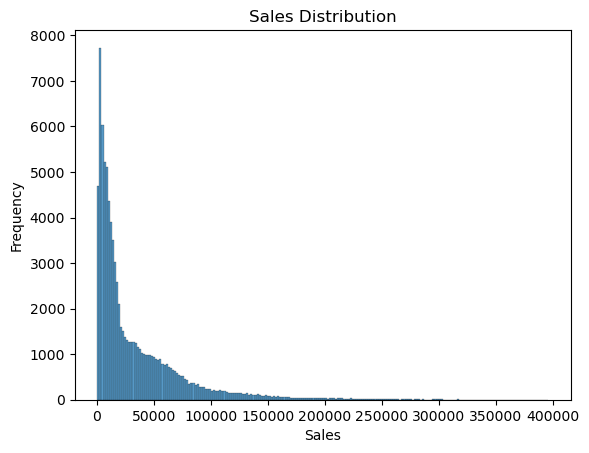

In [45]:
sns.histplot(df['Sales'])
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

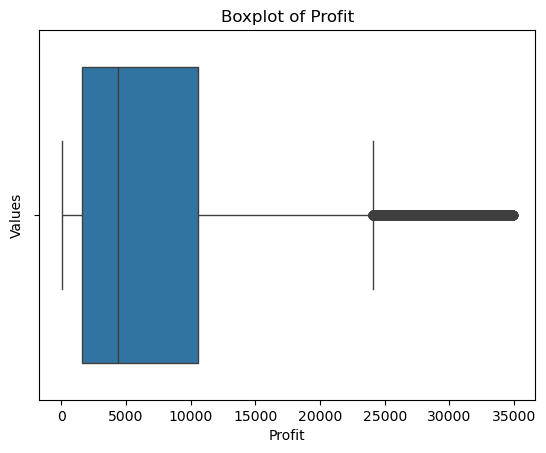

In [46]:
sns.boxplot(x=df['Profit'])
plt.title("Boxplot of Profit")
plt.xlabel("Profit")
plt.ylabel("Values")
plt.show()

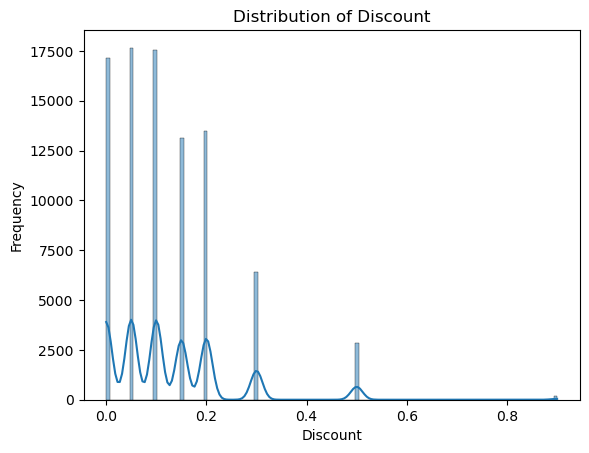

In [47]:
sns.histplot(df['Discount'], kde=True)
plt.title("Distribution of Discount")
plt.xlabel("Discount")
plt.ylabel("Frequency")
plt.show()

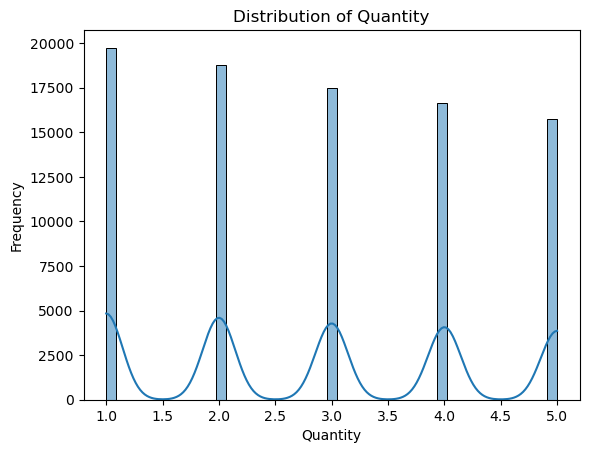

In [48]:
sns.histplot(df['Quantity'], kde=True)
plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

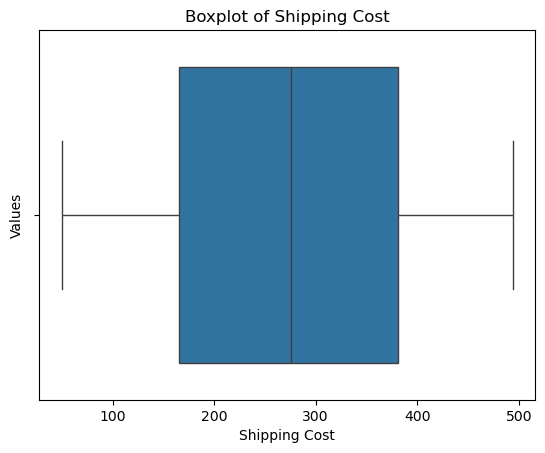

In [49]:
sns.boxplot(x=df['Shipping_Cost'])
plt.title("Boxplot of Shipping Cost")
plt.xlabel("Shipping Cost")
plt.ylabel("Values")
plt.show()

In [50]:
df[['Sales','Profit','Discount','Quantity','Shipping_Cost']].skew()

Sales            2.407705
Profit           1.490181
Discount         1.823802
Quantity         0.106886
Shipping_Cost   -0.007566
dtype: float64

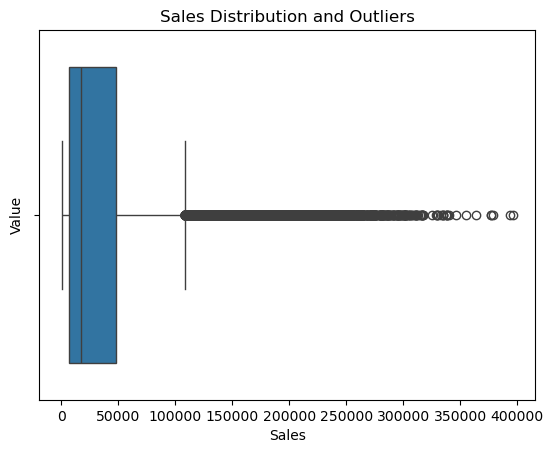

In [51]:
sns.boxplot(x=df['Sales'])

plt.title("Sales Distribution and Outliers")
plt.xlabel("Sales")
plt.ylabel("Value")

plt.show()

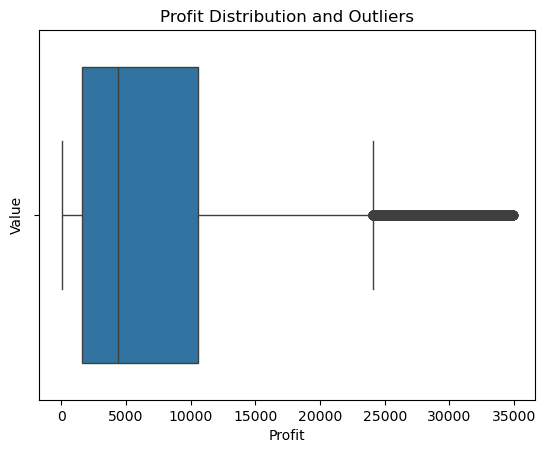

In [52]:
sns.boxplot(x=df['Profit'])
plt.title("Profit Distribution and Outliers")
plt.xlabel("Profit")
plt.ylabel("Value")

plt.show()

In [53]:
#B. Categorical Analysis

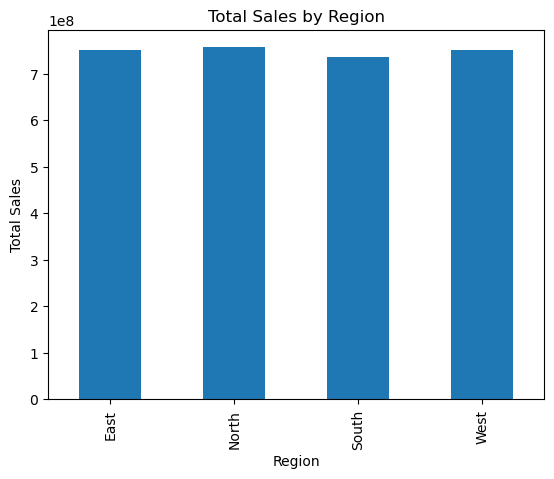

In [54]:
df.groupby('Region')['Sales'].sum().plot(kind='bar')
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

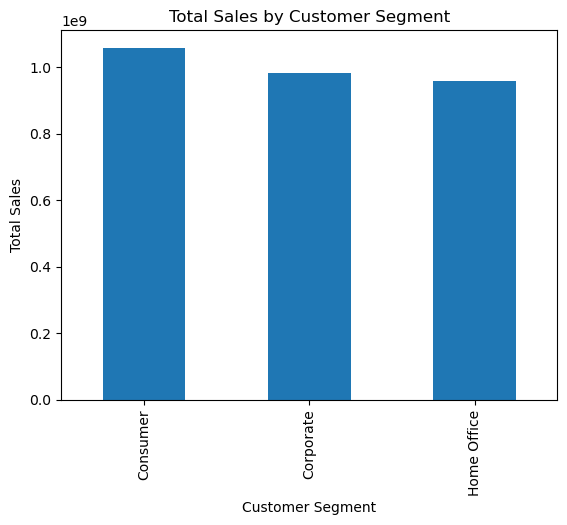

In [55]:
df.groupby('Customer_Segment')['Sales'].sum().plot(kind='bar')
plt.title("Total Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")
plt.show()

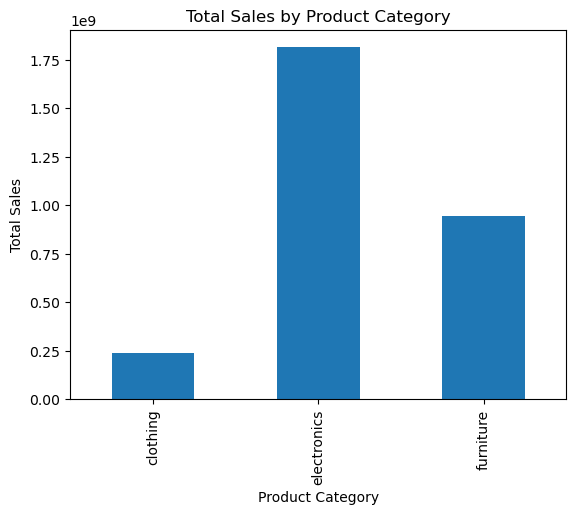

In [56]:
df.groupby('Product_Category')['Sales'].sum().plot(kind='bar')
plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.show()

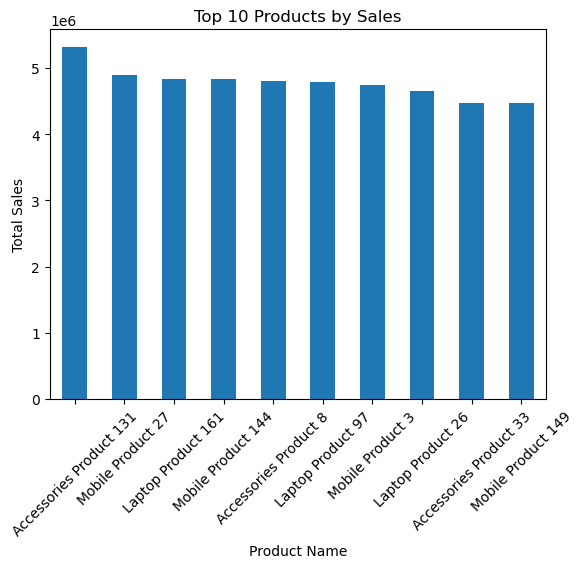

In [57]:
top_products = df.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar')
plt.title("Top 10 Products by Sales")
plt.xlabel("Product Name")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

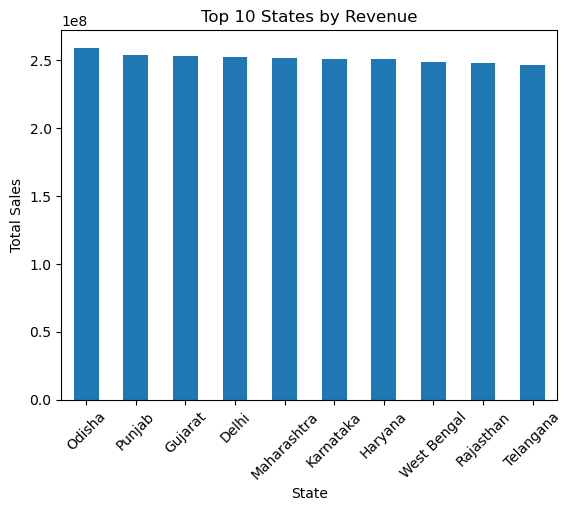

In [58]:
top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)
top_states.plot(kind='bar')
plt.title("Top 10 States by Revenue")
plt.xlabel("State")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

In [59]:
#C. Bivariate Analysis

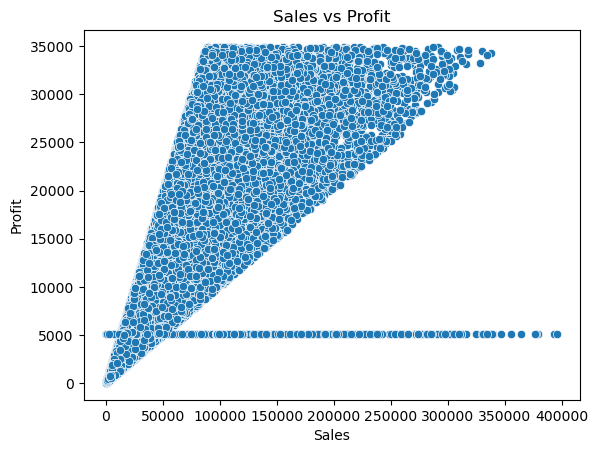

In [60]:
sns.scatterplot(x='Sales', y='Profit', data=df)
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

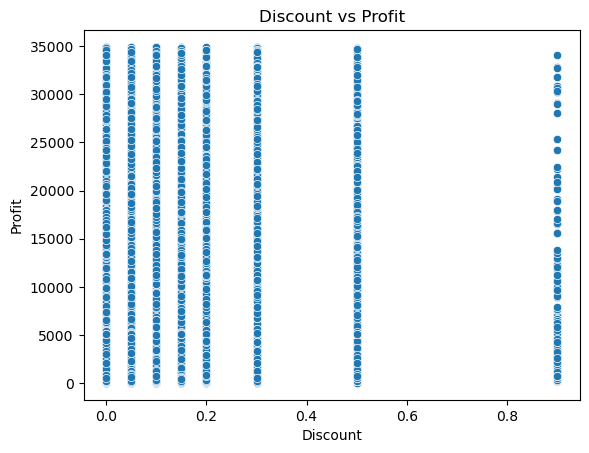

In [61]:
sns.scatterplot(x='Discount', y='Profit', data=df)
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()
#A negative relationship is observed between discount and profit, suggesting that higher discounts tend to reduce profitability.

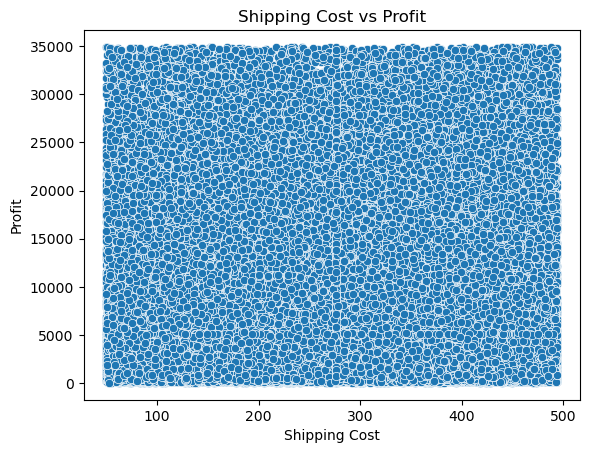

In [62]:
sns.scatterplot(x='Shipping_Cost', y='Profit', data=df)
plt.title("Shipping Cost vs Profit")
plt.xlabel("Shipping Cost")
plt.ylabel("Profit")
plt.show()
#Shipping cost shows a weak or slightly negative relationship with profit, indicating higher costs may reduce margins.

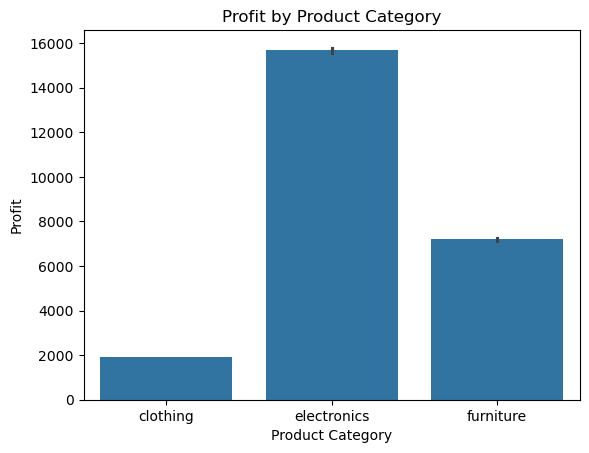

In [63]:
sns.barplot(x='Product_Category', y='Profit', data=df)
plt.title("Profit by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Profit")
plt.show()

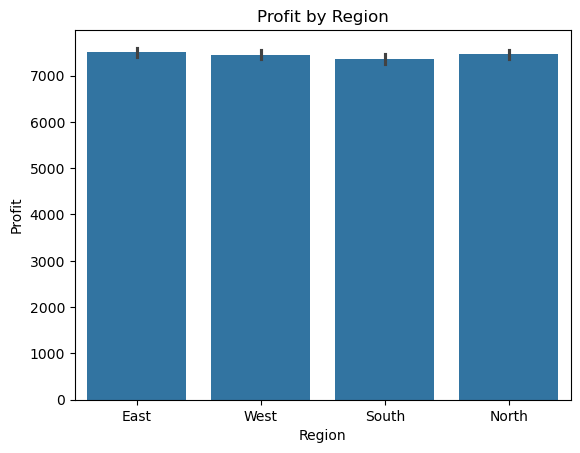

In [64]:
sns.barplot(x='Region', y='Profit', data=df)
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.show()

In [65]:
#D. Time-Based Analysis

In [66]:
monthly_sales = df.groupby(df['Order_Date'].dt.to_period('M'))['Sales'].sum()

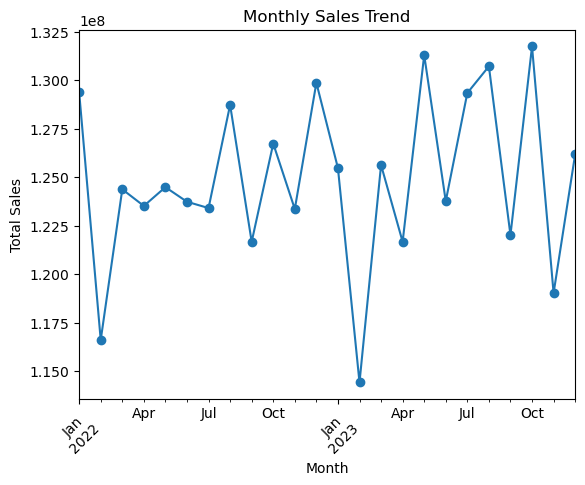

In [67]:
monthly_sales = df.groupby(df['Order_Date'].dt.to_period('M'))['Sales'].sum()
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

In [68]:
quarterly_sales = df.groupby(df['Order_Date'].dt.to_period('Q'))['Sales'].sum()

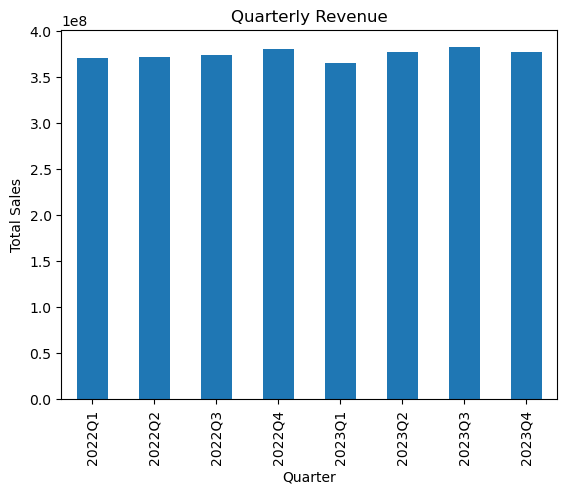

In [69]:
quarterly_sales.plot(kind='bar')
plt.title("Quarterly Revenue")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.show()

C:\Users\91818\AppData\Local\Temp\ipykernel_12852\675478252.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Month'] = df['Order_Date'].dt.month


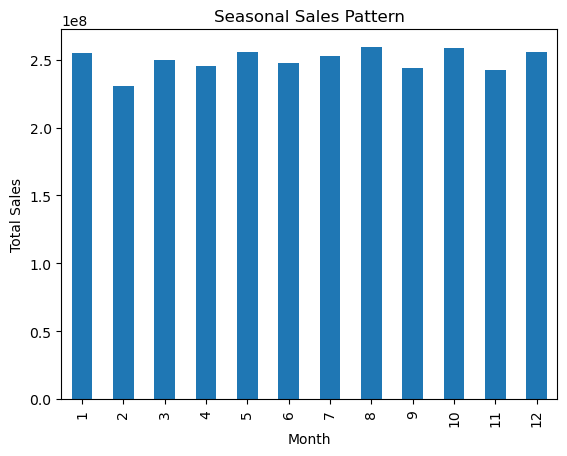

In [70]:
df['Month'] = df['Order_Date'].dt.month

seasonal_sales = df.groupby('Month')['Sales'].sum()

seasonal_sales.plot(kind='bar')
plt.title("Seasonal Sales Pattern")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

In [71]:
monthly_sales = df.groupby(df['Order_Date'].dt.to_period('M'))['Sales'].sum()

best_month = monthly_sales.idxmax()
worst_month = monthly_sales.idxmin()

print("Best Month:", best_month)
print("Worst Month:", worst_month)

Best Month: 2023-10
Worst Month: 2023-02


In [72]:
#E. Customer Analysis

In [73]:
customer_sales = df.groupby('Customer_ID')['Sales'].sum().sort_values(ascending=False)

top_sales = customer_sales.head(int(0.2 * len(customer_sales))).sum()

print("Top 20% Contribution:", (top_sales / customer_sales.sum()) * 100)

Top 20% Contribution: 29.844578283385303


In [74]:
repeat_customers = df['Customer_ID'].value_counts()

# Customers with more than 1 order
repeat_count = (repeat_customers > 1).sum()
total_customers = df['Customer_ID'].nunique()

print("Repeat Customers:", repeat_count)
print("Repeat Customer %:", (repeat_count / total_customers) * 100)

Repeat Customers: 4000
Repeat Customer %: 100.0


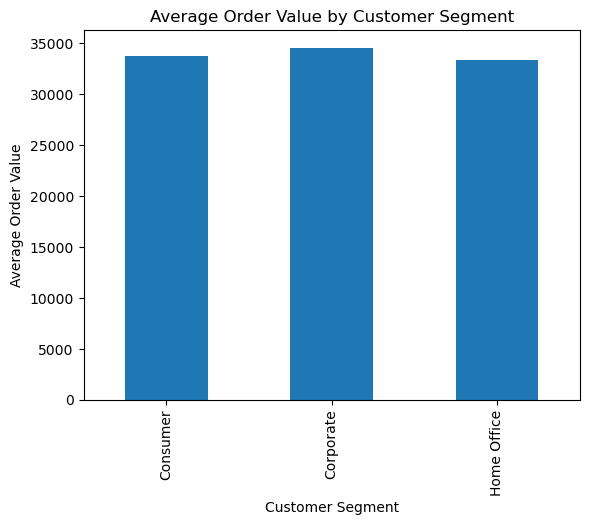

In [75]:
aov = df.groupby('Customer_Segment')['Sales'].mean()
aov.plot(kind='bar')
plt.title("Average Order Value by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Order Value")
plt.show()

In [76]:
#F. Correlation Analysis

In [77]:
corr = df[['Sales', 'Profit', 'Discount', 'Quantity', 'Shipping_Cost']].corr()

print(corr)

                  Sales    Profit  Discount  Quantity  Shipping_Cost
Sales          1.000000  0.823046 -0.051993  0.241612       0.001745
Profit         0.823046  1.000000 -0.050753  0.222156       0.004678
Discount      -0.051993 -0.050753  1.000000  0.008495       0.007173
Quantity       0.241612  0.222156  0.008495  1.000000      -0.006099
Shipping_Cost  0.001745  0.004678  0.007173 -0.006099       1.000000


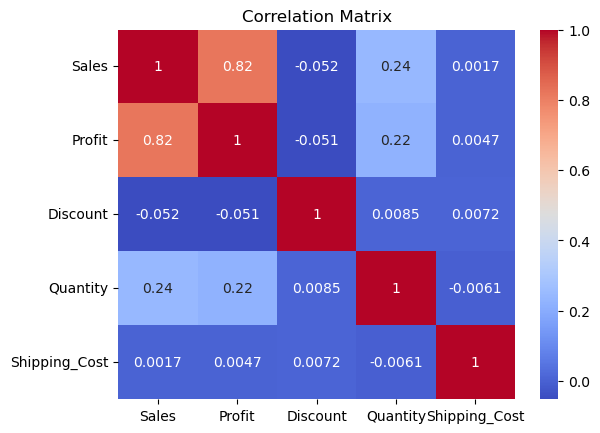

In [78]:
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# PHASE 3 – BUSINESS INSIGHTS

# Which region is most profitable?

In [79]:
df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
#The North region is the most profitable, contributing the highest total profit among all regions.

Region
North    1.658970e+08
East     1.652590e+08
West     1.643165e+08
South    1.623205e+08
Name: Profit, dtype: float64

#  Which product category should be promote ?

In [80]:
df.groupby('Product_Category')['Profit'].sum().sort_values(ascending=False)
#Electronics category should be promoted as it generates the highest profit among all product categories.

Product_Category
electronics    3.610475e+08
furniture      2.336514e+08
clothing       6.309405e+07
Name: Profit, dtype: float64

# Is discount strategy hurting profitability?

In [81]:
df[['Discount', 'Profit']].corr()
#The discount strategy has a slight negative impact on profitability, but the relationship is weak.

,Discount,Profit
Discount,1.000000,-0.050753
Profit,-0.050753,1.000000


# Which customer segment generates most revenue?

In [82]:
df.groupby('Customer_Segment')['Sales'].sum().sort_values(ascending=False)
# Corporate segment generates the highest revenue among all customer segments.

Customer_Segment
Consumer       1.058631e+09
Corporate      9.811291e+08
Home Office    9.574024e+08
Name: Sales, dtype: float64

# Is shipping cost impacting margins?


In [83]:
df[['Shipping_Cost', 'Profit']].corr()
#Shipping cost has no significant impact on profitability, as the correlation is nearly zero

,Shipping_Cost,Profit
Shipping_Cost,1.000000,0.004678
Profit,0.004678,1.000000


# PHASE 4 – VISUALIZATION REQUIREMENTS

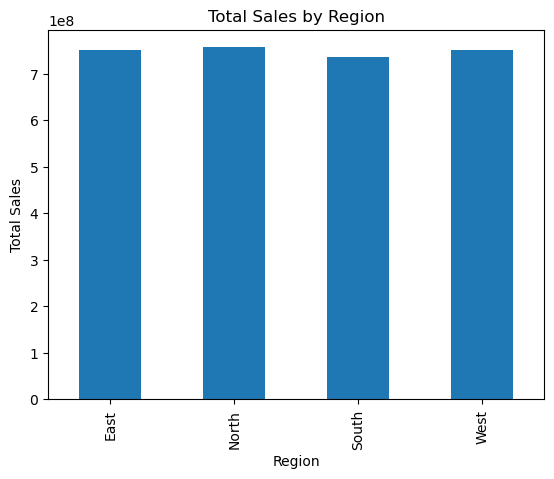

In [84]:
df.groupby('Region')['Sales'].sum().plot(kind='bar')
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()
#Insight: north region having highest sales

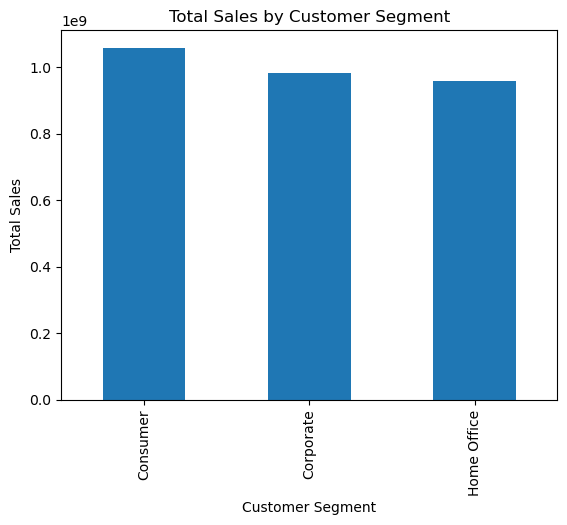

In [85]:
df.groupby('Customer_Segment')['Sales'].sum().plot(kind='bar')
plt.title("Total Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")
plt.show()
#Insight : in customer segment corporate has high sales

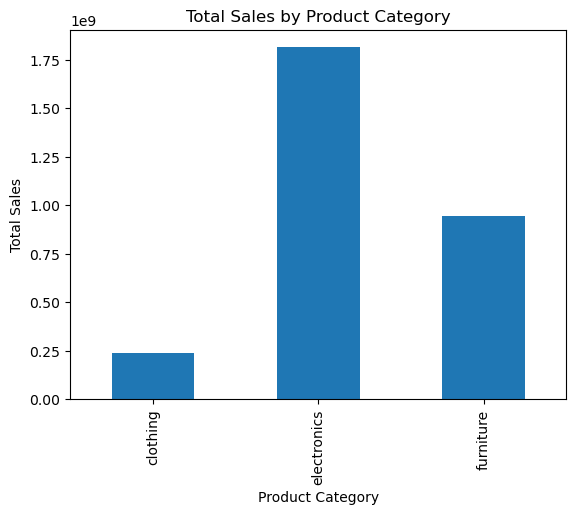

In [86]:
df.groupby('Product_Category')['Sales'].sum().plot(kind='bar')
plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.show()
#Insights : in product category Eelectronics has a high sales

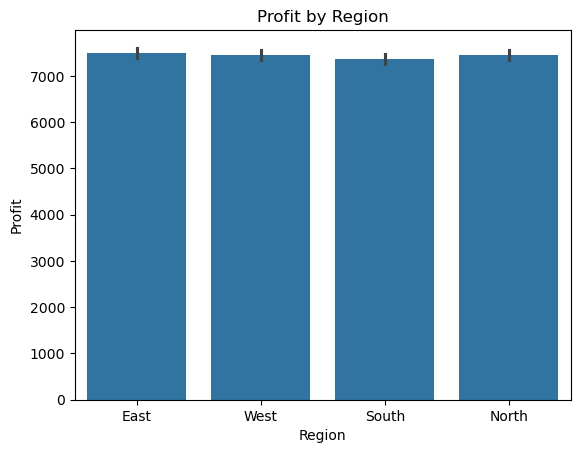

In [87]:
sns.barplot(x='Region', y='Profit', data=df)
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.show()
##Insight : East region has a highest profit

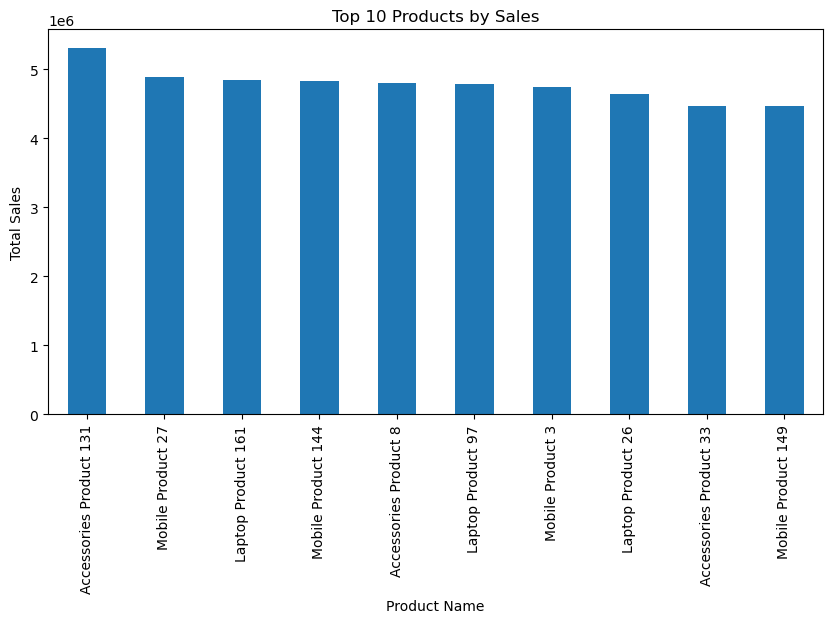

In [88]:
plt.figure(figsize=(10,5))
df.groupby("Product_Name")["Sales"].sum().nlargest(10).plot(kind="bar")
plt.title("Top 10 Products by Sales")
plt.xlabel("Product Name")
plt.ylabel("Total Sales")
plt.show()
#Insights:Accessories is the among 10 products by sales

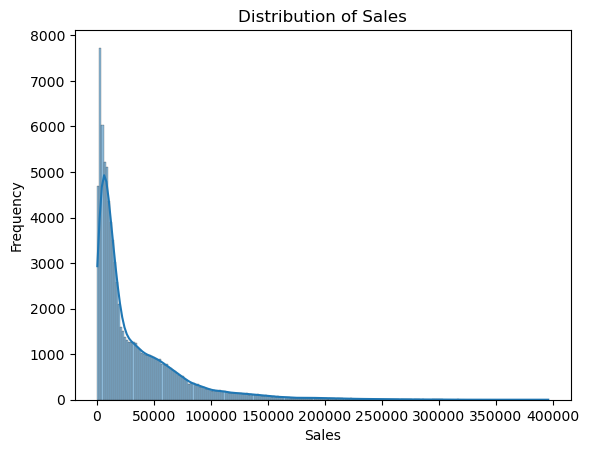

In [89]:
sns.histplot(df['Sales'], kde=True)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

#Insight: Sales are right-skewed, indicating few high-value transactions.

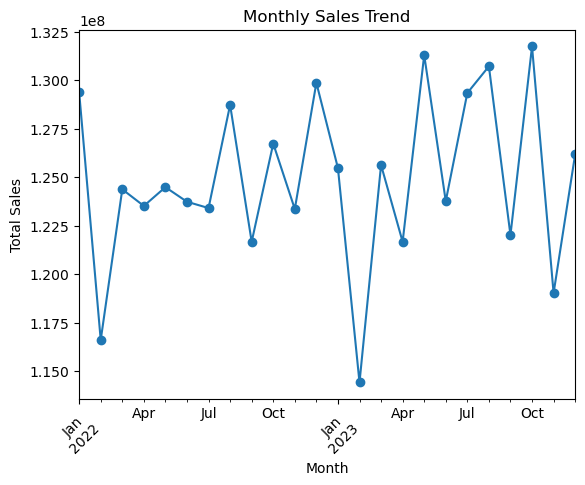

In [91]:
monthly_sales = df.groupby(df['Order_Date'].dt.to_period('M'))['Sales'].sum()
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

In [90]:
df.to_csv("cleaned_sales_data.csv", index=False)